# Intrusive PCE MPC Benchmark

This notebook compares intrusive-PCE MPC across different PCE orders for two controller formulations:

- mean-constrained MPC
- chance-constrained MPC

The notebook focuses on compact visual comparisons:

- Monte Carlo averages of objective value and constraint violation for open-loop and closed-loop MPC
- closed-loop state and control trajectories for each tested PCE order
- open-loop state and control trajectories for each tested PCE order


In [1]:
from pathlib import Path
import sys
import warnings

from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

repo_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path(".").resolve(), Path("..").resolve(), Path("../..").resolve()]
I4B_ROOT = next((path for path in repo_candidates if (path / "src").exists() and (path / "data").exists()), None)
if I4B_ROOT is None:
    raise FileNotFoundError("Could not locate the i4b repository root from the current working directory.")
if str(I4B_ROOT) not in sys.path:
    sys.path.insert(0, str(I4B_ROOT))

import src.disturbances as disturbances
import src.models.model_buildings as model_buildings
import src.models.model_buildings_pce as model_buildings_pce
import src.models.model_hvac as model_hvac
from src.controller.pc_mpc.intrusive_evaluation import (
    benchmark_intrusive_open_loop_pce_orders,
    benchmark_intrusive_pce_orders,
    build_intrusive_mpc_solver,
    extract_intrusive_trajectory,
    lower_quantile_from_moments,
    room_moments_from_state_traj,
)
from data.buildings import i4c


In [2]:
method = "2R2C"
pce_orders = [0, 1, 2]

h = 3600
nk = 24
closed_loop_steps = 24

eps_chance = 0.05
constraint_handling = "hard"  # choose from: "hard", "soft"
ws = 0.2
mdot_hp = 0.25

theta_bar = np.ones(2)
L = np.diag([0.2, 0.1])

n_uncertainty_samples = 8
closed_loop_plot_sample_index = 0
rng = np.random.default_rng(7)
xi_samples = rng.standard_normal((n_uncertainty_samples, L.shape[1]))
xi_samples[0] = np.array([1.0, -0.5])

if constraint_handling not in {"hard", "soft"}:
    raise ValueError("constraint_handling must be 'hard' or 'soft'.")

soft_lower_constraint = constraint_handling == "soft"
handling_label = constraint_handling.capitalize()
controller_cases = {
    f"{handling_label} mean-constrained": None,
    f"{handling_label} chance-constrained": eps_chance,
}
controller_color_map = {
    f"{handling_label} mean-constrained": "tab:blue",
    f"{handling_label} chance-constrained": "tab:orange",
}

disturbance_cols = ["T_amb", "Qdot_gains", "T_room_set_lower", "grid"]


Important: `pce_order = 0` is the deterministic baseline.

`constraint_handling` and the mean/chance formulation are independent choices:

- `constraint_handling = "hard"`: enforce the lower comfort constraint as a hard NLP constraint
- `constraint_handling = "soft"`: relax the lower comfort constraint with slack and penalize that slack in the objective
- `chance_epsilon = None`: mean-constrained formulation
- `chance_epsilon = eps_chance`: chance-constrained formulation


In [3]:
nominal_building = model_buildings.Building(
    params=i4c,
    mdot_hp=mdot_hp,
    method=method,
    T_room_set_lower=20,
)

hp_model = model_hvac.Heatpump_AW(mdot_HP=mdot_hp)

raw_disturbances = disturbances.generate_disturbances_all(
    building_model=nominal_building,
    timestep=h,
    GRID_ON=False,
    repo_filepath=str(I4B_ROOT),
)
disturbances_df = raw_disturbances.loc[:, disturbance_cols].iloc[: nk + closed_loop_steps + 2]

x0_dict = {key: 20.0 for key in nominal_building.state_keys}
if "T_wall" in x0_dict:
    x0_dict["T_wall"] = 19.0
if "T_hp_ret" in x0_dict:
    x0_dict["T_hp_ret"] = 22.0

x0_det = np.asarray([x0_dict[key] for key in nominal_building.state_keys], dtype=float)

def intrusive_building_factory(order: int):
    return model_buildings_pce.BuildingPCEIntrusive(
        params=i4c,
        mdot_hp=mdot_hp,
        method=method,
        T_room_set_lower=20,
        pce_order=order,
        theta_bar=theta_bar,
        L=L,
    )

def true_building_factory(xi_sample: np.ndarray):
    theta = theta_bar + L @ np.asarray(xi_sample, dtype=float)
    params = dict(i4c)
    params["H_ve"] = i4c["H_ve"] * theta[0]
    params["H_tr"] = i4c["H_tr"] * theta[1]
    return model_buildings.Building(
        params=params,
        mdot_hp=mdot_hp,
        method=method,
        T_room_set_lower=20,
    )

def solve_open_loop_case(order: int, label: str, chance_epsilon):
    intrusive_building = intrusive_building_factory(order)
    x0_pc = intrusive_building.lift_deterministic_state(x0_det)
    P0 = disturbances_df.iloc[: nk + 1].loc[:, disturbance_cols].to_numpy()

    mpc = build_intrusive_mpc_solver(
        hp_model=hp_model,
        building_model=intrusive_building,
        disturbance_count=len(disturbance_cols),
        h=h,
        nk=nk,
        ws=ws,
        resultdir="results_intrusive_pce",
        resultfile=f"open_loop_order{order}_{label.lower().replace(' ', '_')}",
        chance_epsilon=chance_epsilon,
        soft_lower_constraint=soft_lower_constraint,
    )
    mpc.update_NLP(x0_pc)
    uk, _, res = mpc.solve_NLP(P0, return_res=True)
    x_traj, u_seq, _ = extract_intrusive_trajectory(res["x"], mpc)
    mean_room, std_room = room_moments_from_state_traj(x_traj, intrusive_building)
    chance_lower = lower_quantile_from_moments(mean_room, std_room, eps_chance)
    interval_z = NormalDist().inv_cdf(0.975)
    interval_lower = mean_room - interval_z * std_room
    interval_upper = mean_room + interval_z * std_room

    return {
        "controller": label,
        "chance_epsilon": chance_epsilon,
        "objective_value": float(np.asarray(res["f"]).squeeze()),
        "u_seq": np.asarray(u_seq).reshape(-1),
        "mean_room": mean_room,
        "chance_lower": chance_lower,
        "std_room": std_room,
        "interval_lower": interval_lower,
        "interval_upper": interval_upper,
        "setpoint": P0[:, disturbance_cols.index("T_room_set_lower")],
    }


## Closed-Loop Monte Carlo Comparison

A single figure compares Monte Carlo average realized objective value and Monte Carlo average constraint violation rate for the closed-loop controller across PCE orders.


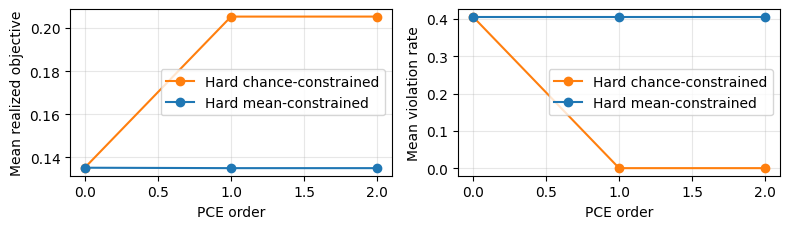

In [4]:
benchmark = benchmark_intrusive_pce_orders(
    orders=pce_orders,
    controller_cases=controller_cases,
    intrusive_building_factory=intrusive_building_factory,
    true_building_factory=true_building_factory,
    nominal_building=nominal_building,
    hp_model=hp_model,
    disturbances=disturbances_df,
    disturbance_cols=disturbance_cols,
    x0_det=x0_det,
    nk=nk,
    h=h,
    closed_loop_steps=closed_loop_steps,
    eval_epsilon=eps_chance,
    xi_samples=xi_samples,
    ws=ws,
    soft_lower_constraint=soft_lower_constraint,
)
summary = benchmark["summary"]
step_metrics = benchmark["step_metrics"]

fig, axes = plt.subplots(1, 2, figsize=(8, 2.4), sharex=True)

for label, group in summary.groupby("controller"):
    color = controller_color_map[label]
    axes[0].plot(group["pce_order"], group["realized_objective_total_mean"], marker="o", color=color, label=label)
    axes[1].plot(group["pce_order"], group["violation_probability_mean"], marker="o", color=color, label=label)

axes[0].set_ylabel("Mean realized objective")
axes[1].set_ylabel("Mean violation rate")

for ax in axes:
    ax.set_xlabel("PCE order")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## Open-Loop vs Closed-Loop Monte Carlo

The next figure compares Monte Carlo average realized objective value and Monte Carlo average constraint violation rate for open-loop and closed-loop MPC, using the same uncertainty samples.


,pce_order,controller,realized_objective_total_mean,violation_probability_mean,mode
0,0,Hard chance-constrained,0.135238,0.406250,Closed-loop
1,0,Hard mean-constrained,0.135238,0.406250,Closed-loop
2,1,Hard chance-constrained,0.205235,0.000000,Closed-loop
3,1,Hard mean-constrained,0.135044,0.406250,Closed-loop
4,2,Hard chance-constrained,0.205244,0.000000,Closed-loop
5,2,Hard mean-constrained,0.135044,0.406250,Closed-loop
6,0,Hard chance-constrained,0.128749,0.286458,Open-loop
7,0,Hard mean-constrained,0.128749,0.286458,Open-loop
8,1,Hard chance-constrained,0.197924,0.000000,Open-loop
9,1,Hard mean-constrained,0.128569,0.286458,Open-loop


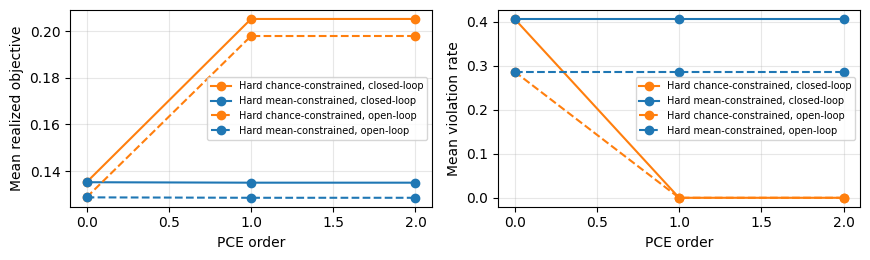

In [5]:
open_loop_benchmark = benchmark_intrusive_open_loop_pce_orders(
    orders=pce_orders,
    controller_cases=controller_cases,
    intrusive_building_factory=intrusive_building_factory,
    true_building_factory=true_building_factory,
    nominal_building=nominal_building,
    hp_model=hp_model,
    disturbances=disturbances_df,
    disturbance_cols=disturbance_cols,
    x0_det=x0_det,
    nk=nk,
    h=h,
    eval_epsilon=eps_chance,
    xi_samples=xi_samples,
    ws=ws,
    soft_lower_constraint=soft_lower_constraint,
)
open_loop_summary = open_loop_benchmark["summary"]
open_loop_step_metrics = open_loop_benchmark["step_metrics"]

comparison_frames = []
for mode, df in (("Closed-loop", summary), ("Open-loop", open_loop_summary)):
    comparison_frames.append(
        df.loc[:, ["pce_order", "controller", "realized_objective_total_mean", "violation_probability_mean"]]
        .assign(mode=mode)
    )

mc_comparison = pd.concat(comparison_frames, ignore_index=True)
display(mc_comparison.sort_values(["mode", "pce_order", "controller"]).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(8.8, 2.7), sharex=True)
mode_linestyle = {"Closed-loop": "-", "Open-loop": "--"}

for (mode, label), group in mc_comparison.groupby(["mode", "controller"]):
    color = controller_color_map[label]
    linestyle = mode_linestyle[mode]
    legend_label = f"{label}, {mode.lower()}"
    axes[0].plot(
        group["pce_order"],
        group["realized_objective_total_mean"],
        marker="o",
        color=color,
        linestyle=linestyle,
        label=legend_label,
    )
    axes[1].plot(
        group["pce_order"],
        group["violation_probability_mean"],
        marker="o",
        color=color,
        linestyle=linestyle,
        label=legend_label,
    )

axes[0].set_ylabel("Mean realized objective")
axes[1].set_ylabel("Mean violation rate")

for ax in axes:
    ax.set_xlabel("PCE order")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, ncol=1, loc="best")

plt.tight_layout()
plt.show()



## Closed-Loop Trajectories By PCE Order

For each tested PCE order, the figure below shows one representative closed-loop realization, with realized room temperature on the left axis and applied supply temperature on the right axis.


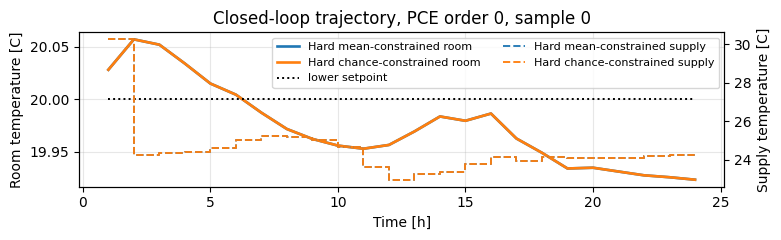

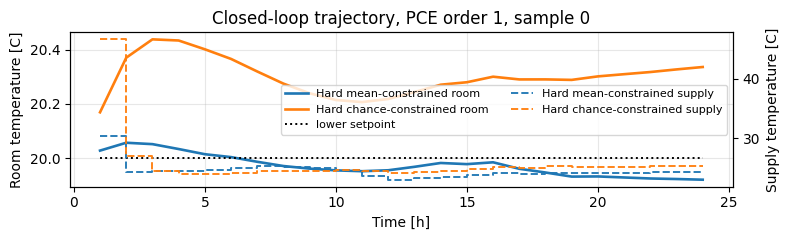

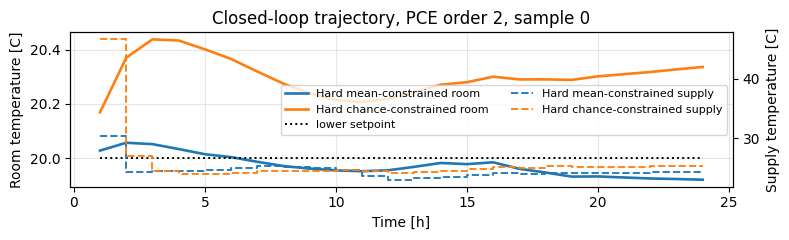

In [6]:
closed_loop_plot_data = step_metrics.loc[
    step_metrics["sample_index"] == closed_loop_plot_sample_index
].copy()

if closed_loop_plot_data.empty:
    raise ValueError("No closed-loop data found for closed_loop_plot_sample_index.")

for order in pce_orders:
    order_data = closed_loop_plot_data.loc[
        closed_loop_plot_data["pce_order"] == order
    ].copy()
    if order_data.empty:
        continue

    fig, ax_room = plt.subplots(figsize=(8, 2.5))
    ax_supply = ax_room.twinx()

    for label, group in order_data.groupby("controller", sort=False):
        color = controller_color_map[label]
        group = group.sort_values("time_h")
        ax_room.plot(
            group["time_h"],
            group["T_room_true"],
            color=color,
            linewidth=1.9,
            label=f"{label} room",
        )
        ax_supply.step(
            group["time_h"],
            group["T_hp_sup"],
            where="post",
            color=color,
            linewidth=1.4,
            linestyle="--",
            alpha=0.95,
            label=f"{label} supply",
        )

    setpoint = (
        order_data.sort_values("time_h")
        .groupby("time_h", as_index=False)["T_set_lower"]
        .first()
    )
    ax_room.plot(
        setpoint["time_h"],
        setpoint["T_set_lower"],
        "k:",
        linewidth=1.4,
        label="lower setpoint",
    )

    ax_room.set_title(
        f"Closed-loop trajectory, PCE order {order}, sample {closed_loop_plot_sample_index}"
    )
    ax_room.set_xlabel("Time [h]")
    ax_room.set_ylabel("Room temperature [C]")
    ax_supply.set_ylabel("Supply temperature [C]")
    ax_room.grid(True, alpha=0.3)

    handles_room, labels_room = ax_room.get_legend_handles_labels()
    handles_supply, labels_supply = ax_supply.get_legend_handles_labels()
    ax_room.legend(
        handles_room + handles_supply,
        labels_room + labels_supply,
        fontsize=8,
        ncol=2,
        loc="best",
    )

    plt.tight_layout()
    plt.show()


## Closed-Loop Uncertainty Propagation By PCE Order

For each tested PCE order, the figure below shows the empirical closed-loop state and control distribution over all sampled uncertainty realizations. The shaded regions are empirical 95% quantile bands, so this is the closed-loop analogue of the open-loop uncertainty plot under receding-horizon MPC.


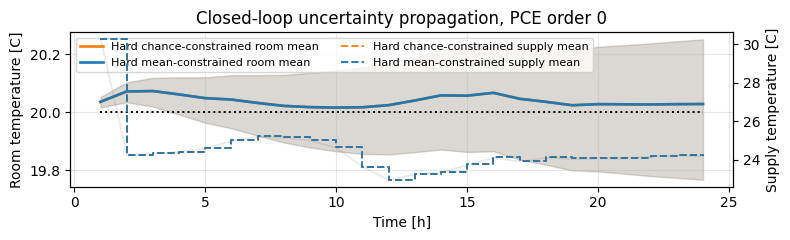

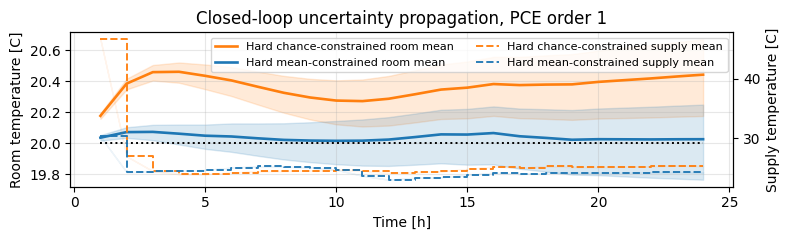

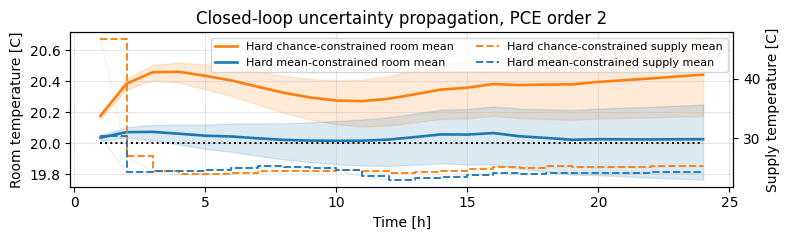

In [7]:
closed_loop_band = (
    step_metrics
    .groupby(["pce_order", "controller", "time_h"], as_index=False)
    .agg(
        T_room_mean=("T_room_true", "mean"),
        T_room_q025=("T_room_true", lambda x: x.quantile(0.025)),
        T_room_q975=("T_room_true", lambda x: x.quantile(0.975)),
        T_hp_sup_mean=("T_hp_sup", "mean"),
        T_hp_sup_q025=("T_hp_sup", lambda x: x.quantile(0.025)),
        T_hp_sup_q975=("T_hp_sup", lambda x: x.quantile(0.975)),
        T_set_lower=("T_set_lower", "mean"),
    )
)

for order in pce_orders:
    order_band = closed_loop_band.loc[
        closed_loop_band["pce_order"] == order
    ].copy()
    if order_band.empty:
        continue

    fig, ax_room = plt.subplots(figsize=(8,2.5))
    ax_supply = ax_room.twinx()

    for label, group in order_band.groupby("controller", sort=False):
        color = controller_color_map[label]
        group = group.sort_values("time_h")

        ax_room.fill_between(
            group["time_h"],
            group["T_room_q025"],
            group["T_room_q975"],
            color=color,
            alpha=0.16,
            #label=f"{label} room 95% band",
        )
        ax_room.plot(
            group["time_h"],
            group["T_room_mean"],
            color=color,
            linewidth=1.9,
            label=f"{label} room mean",
        )

        ax_supply.fill_between(
            group["time_h"],
            group["T_hp_sup_q025"],
            group["T_hp_sup_q975"],
            color=color,
            alpha=0.08,
        )
        ax_supply.step(
            group["time_h"],
            group["T_hp_sup_mean"],
            where="post",
            color=color,
            linewidth=1.4,
            linestyle="--",
            alpha=0.95,
            label=f"{label} supply mean",
        )

    setpoint = (
        order_band.sort_values("time_h")
        .groupby("time_h", as_index=False)["T_set_lower"]
        .first()
    )
    ax_room.plot(
        setpoint["time_h"],
        setpoint["T_set_lower"],
        "k:",
        linewidth=1.4,
        #label="lower setpoint",
    )

    ax_room.set_title(f"Closed-loop uncertainty propagation, PCE order {order}")
    ax_room.set_xlabel("Time [h]")
    ax_room.set_ylabel("Room temperature [C]")
    ax_supply.set_ylabel("Supply temperature [C]")
    ax_room.grid(True, alpha=0.3)

    handles_room, labels_room = ax_room.get_legend_handles_labels()
    handles_supply, labels_supply = ax_supply.get_legend_handles_labels()
    ax_room.legend(
        handles_room + handles_supply,
        labels_room + labels_supply,
        fontsize=8,
        ncol=2,
        loc="best",
    )

    plt.tight_layout()
    plt.show()


## Open-Loop Trajectories By PCE Order

For each tested PCE order, the figure below shows the predicted mean room-temperature trajectory for the mean-constrained and chance-constrained solutions, together with a symmetric 95% uncertainty propagation interval and the open-loop supply setpoint.


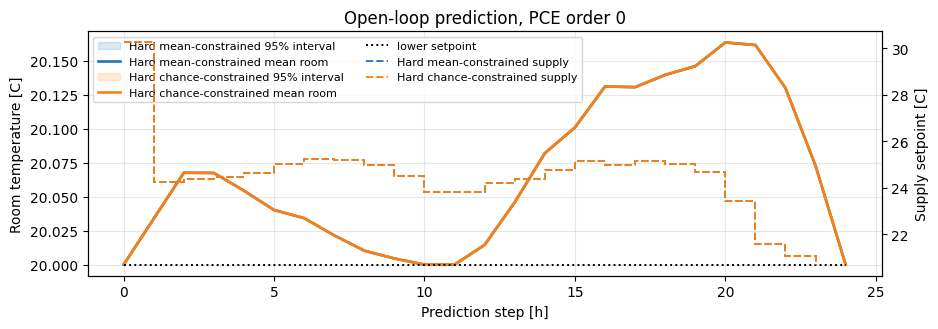

PCE order 0
  Hard mean-constrained: objective=470.21, min lower95-set=-0.00, mean supply=24.40
  Hard chance-constrained: objective=470.21, min lower95-set=-0.00, mean supply=24.40


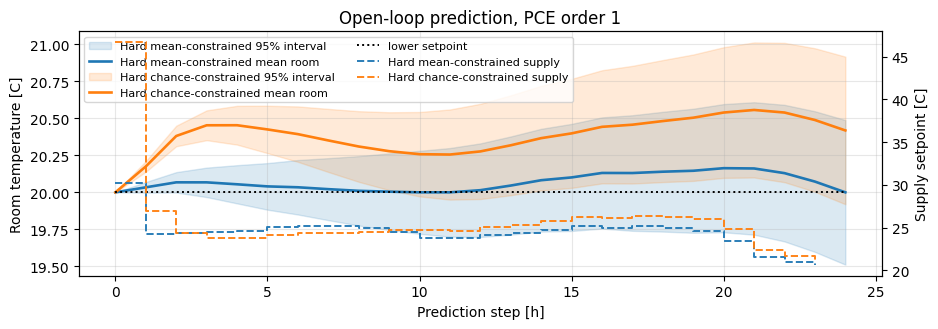

PCE order 1
  Hard mean-constrained: objective=469.47, min lower95-set=-0.41, mean supply=24.39
  Hard chance-constrained: objective=701.30, min lower95-set=-0.00, mean supply=25.60


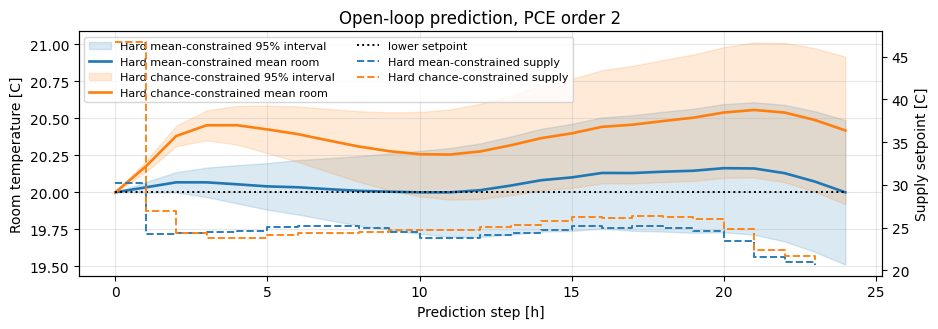

PCE order 2
  Hard mean-constrained: objective=469.47, min lower95-set=-0.41, mean supply=24.39
  Hard chance-constrained: objective=701.33, min lower95-set=-0.00, mean supply=25.60


In [8]:
open_loop_results = {
    order: {
        label: solve_open_loop_case(order, label, chance_epsilon)
        for label, chance_epsilon in controller_cases.items()
    }
    for order in pce_orders
}

hours_state = np.arange(nk + 1) * h / 3600.0
hours_control = np.arange(nk) * h / 3600.0

for order in pce_orders:
    fig, ax_room = plt.subplots(figsize=(9.4, 3.4))
    ax_supply = ax_room.twinx()


    for label, result in open_loop_results[order].items():
        color = controller_color_map[label]
        ax_room.fill_between(
            hours_state,
            result["interval_lower"],
            result["interval_upper"],
            color=color,
            alpha=0.16,
            label=f"{label} 95% interval",
        )
        ax_room.plot(
            hours_state,
            result["mean_room"],
            color=color,
            linewidth=1.9,
            label=f"{label} mean room",
        )
        ax_supply.step(
            hours_control,
            result["u_seq"],
            where="post",
            color=color,
            linewidth=1.4,
            linestyle="--",
            alpha=0.95,
            label=f"{label} supply",
        )

    ax_room.plot(
        hours_state,
        next(iter(open_loop_results[order].values()))["setpoint"],
        "k:",
        linewidth=1.4,
        label="lower setpoint",
    )

    ax_room.set_title(f"Open-loop prediction, PCE order {order}")
    ax_room.set_xlabel("Prediction step [h]")
    ax_room.set_ylabel("Room temperature [C]")
    ax_supply.set_ylabel("Supply setpoint [C]")
    ax_room.grid(True, alpha=0.3)

    handles_room, labels_room = ax_room.get_legend_handles_labels()
    handles_supply, labels_supply = ax_supply.get_legend_handles_labels()
    ax_room.legend(handles_room + handles_supply, labels_room + labels_supply, fontsize=8, ncol=2, loc="best")

    plt.tight_layout()
    plt.show()

    print(f"PCE order {order}")
    for label, result in open_loop_results[order].items():
        min_margin = float(np.min(result["chance_lower"] - result["setpoint"]))
        print(
            f"  {label}: objective={result['objective_value']:.2f}, "
            f"min lower95-set={min_margin:.2f}, mean supply={np.mean(result['u_seq']):.2f}"
        )
